In [145]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/prafulsrinivasan/gpt4/pytorch/default/1/checkpoint2.pth
/kaggle/input/models/prafulsrinivasan/gpt7/pytorch/default/1/checkpoint2.pth
/kaggle/input/models/prafulsrinivasan/gpt5/pytorch/default/1/checkpoint2.pth


In [146]:
from pathlib import Path
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import urllib.request
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm.auto import tqdm
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tokenizers
from collections import namedtuple
import torch.nn.functional as F

In [147]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [148]:
def download_dataset():
    path=Path("Datasets/shakespeare.txt") #Path is specified
    if not path.is_file():
        path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://homl.info/shakespeare"
        req=urllib.request.Request(url,headers={"User-Agent": "Mozilla/5.0"}) #retrieving the dataset from the url and saving it to the specified path
        with urllib.request.urlopen(req) as response:
            data=response.read()
            path.write_bytes(data)
    return path.read_text()
text=download_dataset()
print(text[:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [149]:
vocab=sorted(set(text.lower()))
print(vocab)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [150]:
class CharacterDataset(Dataset):
    def __init__(self,text,window_size):
        self.text=text
        self.window_size=window_size
    def __len__(self):
        return len(self.text)-self.window_size
    def __getitem__(self,index):
        if index>len(self):
            raise IndexError("Dataset Index out of range")
        chunk=self.text[index:index+self.window_size+1]
        return chunk
        

In [151]:
window_length=256
batch_size=512
dataset=CharacterDataset(text,window_length)
print(dataset[1000])

Second Citizen:
Would you proceed especially against Caius Marcius?

All:
Against him first: he's a very dog to the commonalty.

Second Citizen:
Consider you what services he has done for his country?

First Citizen:
Very well; and could be content to give 


In [152]:
def iterator():
    for chunk in dataset:
        yield chunk

In [153]:
max_length=512
vocab_size=500
tokenizer_model=tokenizers.models.BPE(unk_token="<unk>")
tokenizer=tokenizers.Tokenizer(tokenizer_model)
tokenizer.enable_padding(pad_id=0,pad_token="<pad>")
tokenizer.enable_truncation(max_length=max_length)
tokenizer.pre_tokenizer=tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer_trainer=tokenizers.trainers.BpeTrainer(special_tokens=["<unk>","<pad>","<s>","</s>"],vocab_size=vocab_size)
tokenizer.train_from_iterator(iterator(),trainer=tokenizer_trainer)
tokenizer.decoder = tokenizers.decoders.ByteLevel()

In [154]:
all_texts = [text[i : i + window_length] for i in range(0,len(text) - window_length,50)]
encodings = tokenizer.encode_batch(all_texts)
all_ids = torch.tensor([e.ids for e in encodings], dtype=torch.long)
all_masks = torch.tensor([e.attention_mask for e in encodings], dtype=torch.long)

In [155]:
class PreTokenizedDataset(Dataset):
    def __init__(self, ids, masks):
        self.ids = ids
        self.masks = masks
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        # Slice for input and target
        x = self.ids[index, :-1]
        y = self.ids[index, 1:]
        mask = self.masks[index, :-1]
        return x, mask, y

In [156]:
# def collate_fn(batch):
#     enc_inputs = tokenizer.encode_batch(batch)
#     all_ids = torch.tensor([e.ids for e in enc_inputs])
#     input_ids=all_ids[:,:-1]
#     labels=all_ids[:,1:]
#     attention_masks=torch.tensor([e.attention_mask for e in enc_inputs])[:,:-1]
#     return input_ids, attention_masks, labels

In [157]:
n = len(all_ids)
train_end = int(0.85 * n)
valid_end = int(0.95 * n)
train_dataset=PreTokenizedDataset(all_ids[:train_end],all_masks[:train_end])
valid_dataset=PreTokenizedDataset(all_ids[train_end:valid_end],all_masks[train_end:valid_end])
test_dataset=PreTokenizedDataset(all_ids[valid_end:],all_masks[valid_end:])
train_dataloader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True, num_workers=4, pin_memory=True)
valid_dataloader=DataLoader(valid_dataset,batch_size=batch_size,shuffle=False,num_workers=4, pin_memory=True)
test_dataloader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=4, pin_memory=True)

In [158]:
class SelfAttention(nn.Module):
    def __init__(self,embed_dim):
        super().__init__()
        self.embed_dim=embed_dim
        self.q=nn.Linear(embed_dim,embed_dim)
        self.k=nn.Linear(embed_dim,embed_dim)
        self.v=nn.Linear(embed_dim,embed_dim)
    def forward(self,x, mask=None):
        #input is in x~(B,W,C)
        Q=self.q(x)
        K=self.k(x)
        V=self.v(x)
        score=Q@K.transpose(-1,-2)
        score=score/(self.embed_dim**0.5)
        if mask is not None:
            score=score.masked_fill(mask==0,float('-inf'))
        attention=F.softmax(score,dim=-1)
        out=attention@V
        return out
        

In [159]:
def casual_mask(seq_length,dev):
    return torch.tril(torch.ones(seq_length,seq_length,device=dev))

In [160]:
class MultiHeadAttention(nn.Module):
    def __init__(self,embed_dim,head_num):
        super().__init__()
        self.embed_dim=embed_dim
        self.head_num=head_num
        assert embed_dim%head_num==0
        self.head_dim=embed_dim//head_num
        self.q=nn.Linear(embed_dim,embed_dim)
        self.k=nn.Linear(embed_dim,embed_dim)
        self.v=nn.Linear(embed_dim,embed_dim)
        self.out=nn.Linear(embed_dim,embed_dim)
    def forward(self,x,mask=None):
        B,T,C=x.shape
        Q=self.q(x)
        K=self.k(x)
        V=self.v(x)
        Q=Q.view(B,T,self.head_num,self.head_dim).transpose(1,2)
        K=K.view(B,T,self.head_num,self.head_dim).transpose(1,2)
        V=V.view(B,T,self.head_num,self.head_dim).transpose(1,2)
        score=Q@K.transpose(-1,-2)
        score=score/(self.head_dim**0.5)
        if mask is not None:
            score=score.masked_fill(mask==0,float('-inf'))
        attention=F.softmax(score,dim=-1)
        out=attention@V
        out=out.transpose(1,2).contiguous().view(B,T,C)
        out=self.out(out)
        return out

In [161]:
class DecoderBlock(nn.Module):
    def __init__(self,d_model,n_heads):
        super().__init__()
        self.mha=MultiHeadAttention(d_model,n_heads)
        self.dropout=nn.Dropout(p=0.1)
        self.ln1=nn.LayerNorm(d_model)
        self.ff1=nn.Sequential(
            nn.Linear(d_model,4*d_model),
            nn.ReLU(),
            nn.Linear(4*d_model,d_model)
        )
        self.ln2=nn.LayerNorm(d_model)
    def forward(self,x,mask):
        attention=self.mha(x,mask)
        x=x+self.dropout(attention)
        x=self.ln1(x)
        ff1=self.ff1(x)
        x=x+self.dropout(ff1)
        x=self.ln2(x)
        return x

In [162]:
class MiniGPT(nn.Module):
    def __init__(self,d_model,n_heads,vocab_size,n_layers,max_seq_layer):
        super().__init__()
        self.token_embed=nn.Embedding(vocab_size,d_model)
        self.pos_embed=nn.Embedding(max_seq_layer,d_model)
        self.embed_dropout=nn.Dropout(p=0.1)
        self.blocks=nn.ModuleList([
            DecoderBlock(d_model,n_heads)
            for _ in range(n_layers)
        ])
        self.ln=nn.LayerNorm(d_model)
        self.linear=nn.Linear(d_model,vocab_size)
    def forward(self,x,mask):
        B,T=x.shape
        pos=torch.arange(T,device=x.device)
        x=self.embed_dropout(self.token_embed(x)+self.pos_embed(pos))
        mask=casual_mask(T,x.device)
        for block in self.blocks:
            x=block(x,mask)
        x=self.ln(x)
        logits=self.linear(x)
        #we wont be doing softmax for CrossEntropy Calcs
        return logits

In [174]:
model=MiniGPT(256,8,1000,6,window_length).to(device)
# model=nn.DataParallel(model)
model.to(device)

MiniGPT(
  (token_embed): Embedding(1000, 256)
  (pos_embed): Embedding(256, 256)
  (embed_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x DecoderBlock(
      (mha): MultiHeadAttention(
        (q): Linear(in_features=256, out_features=256, bias=True)
        (k): Linear(in_features=256, out_features=256, bias=True)
        (v): Linear(in_features=256, out_features=256, bias=True)
        (out): Linear(in_features=256, out_features=256, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff1): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): ReLU()
        (2): Linear(in_features=1024, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (linear): Linear(in_features=256, out_features=1000, bias=True)
)

In [175]:
loss_fn=nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id("<pad>"))
optimizer=torch.optim.Adam(model.parameters(),lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

In [182]:
checkpoint = torch.load(
    "/kaggle/input/models/prafulsrinivasan/gpt7/pytorch/default/1/checkpoint2.pth",
    map_location=device
)
start_index = checkpoint["epoch1"][-1] + 1
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.to(device)
loss1=checkpoint["loss1"]
epoch1=checkpoint["epoch1"]
accuracy=checkpoint["accuracy"]
print("Loss at checkpoint:", checkpoint["loss1"])
print(f"Resuming training from epoch {start_index}")
torch.save(model.state_dict(), "/kaggle/working/pytorch_model3.bin")

Loss at checkpoint: [4.259292194717808, 3.577371126727054, 3.1622784388692757, 2.923220477606121, 2.802208982015911, 2.7237890582335624, 2.657303716007032, 2.6160293064619364, 2.5785262521944547, 2.5480454219015023, 2.518028089874669, 2.4929302617123255, 2.469226021515696, 2.4568097591400146, 2.4427883499547054, 2.43045028887297, 2.418687011066236, 2.4145563276190507, 2.4116060106377852, 2.4065577544664083, 2.405465897760893, 2.404803909753498, 2.4004439303749487, 2.3989086653056897, 2.391598525800203, 2.386495690596731, 2.3784893123727096, 2.3651183153453625, 2.3518912541238883, 2.3322075479908992, 2.3200330922478125, 2.29581398085544, 2.270992122198406, 2.2494058734492253, 2.2202149064917314, 2.1996815016395166, 2.167170706548189, 2.1442299391094006, 2.1200869146146273, 2.0978550785466243, 2.07143161171361, 2.0517070795360364, 2.031129046490318, 2.0119903087615967, 1.987861404293462, 1.9699823511274237, 1.9560183255296004, 1.9419656364541305, 1.9294246654761464, 1.9155316823407222, 1

In [183]:
# loss1=[]
# epoch1=[]
# accuracy=[]
best_val_loss=float('inf')
for epoch in tqdm(range(120,120)):
    loss_epoch=0
    count=0
    accuracy_epoch=0
    total=0
    valid_loss_acc=0
    valid_count=0
    model.train()
    for batch, (x,mask,y) in enumerate(train_dataloader):
        x,y=x.to(device),y.to(device)
        output=model(x,mask)
        B,T,C=output.shape
        output=output.contiguous().view(B*T,C)
        y=y.contiguous().view(B*T)
        loss=loss_fn(output,y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        loss_epoch+=loss.item()
        accuracy_epoch+=(output.argmax(dim=-1)==y).sum().item()
        total+=y.size(0)
        count+=1
    model.eval()
    with torch.inference_mode():
         for x,mask,y in valid_dataloader:
            x=x.to(device)
            y=y.to(device)
            valid_output=model(x,mask)
            B,T,C=valid_output.shape
            valid_loss_acc+=loss_fn(valid_output.contiguous().view(B*T,C),y.contiguous().view(B*T)).item()
            valid_count+=1
    valid_loss=valid_loss_acc/valid_count
    scheduler.step()
    loss1.append(loss_epoch/count)
    epoch1.append(epoch)
    accuracy.append(accuracy_epoch/total)
    print(f"Valid loss{valid_loss} best loss{best_val_loss}")
    if valid_loss<best_val_loss:
        best_val_loss=valid_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.module.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss_epoch/count,
            'accuracy': accuracy,
            'epoch1': epoch1,
            'loss1': loss1
        },"/kaggle/working/checkpoint2.pth")


0it [00:00, ?it/s]

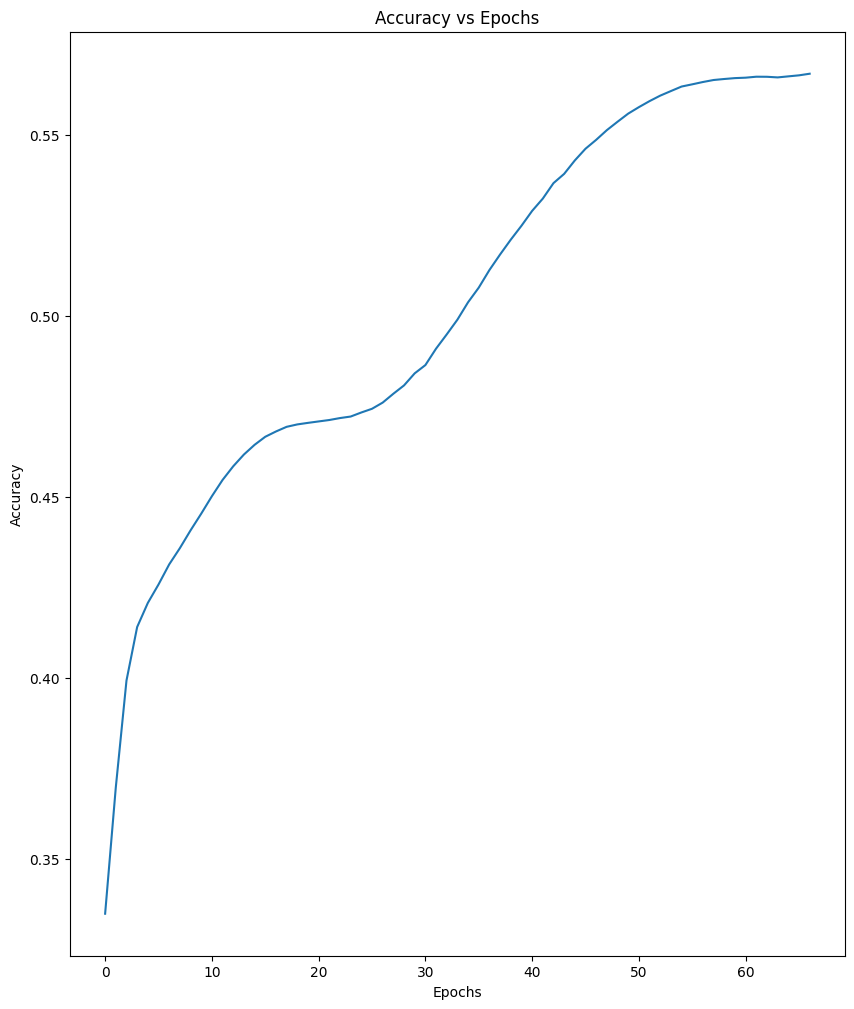

In [184]:
plt.figure(figsize=(10,12))
plt.plot(epoch1,accuracy)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.show()

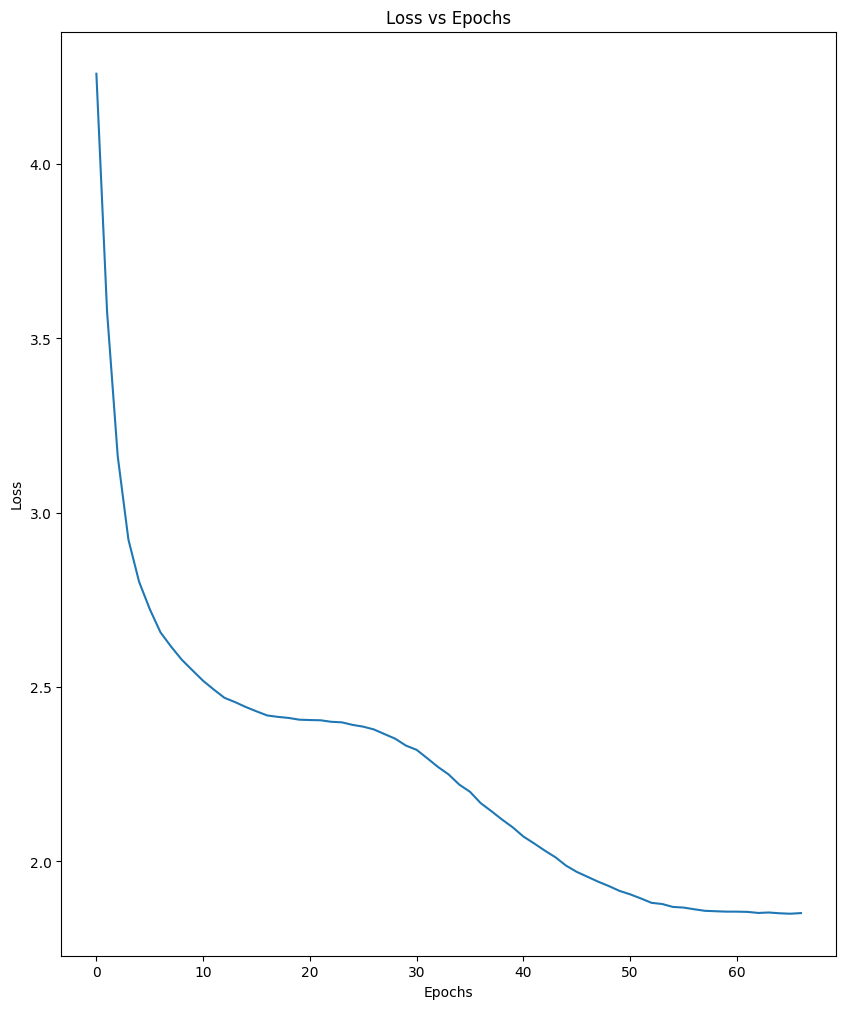

In [185]:
plt.figure(figsize=(10,12))
plt.plot(epoch1,loss1)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

In [199]:

def generate_text(text, num_tokens):
    model.eval()
    encoded = tokenizer.encode(text).ids
    encoded_tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)
    with torch.inference_mode():
        for _ in range(num_tokens):
            input_tensor = encoded_tensor[:, -window_length:]
            y_logits = model(input_tensor, None)['logits']
            y_logits[:, -1, tokenizer.token_to_id("<pad>")] = float('-inf')
            y_logits[:, -1, tokenizer.token_to_id("<unk>")] = float('-inf')
            prob = torch.softmax(y_logits[:, -1, :] / 0.5, dim=-1)
            next_token = torch.multinomial(prob, num_samples=1)
            encoded_tensor = torch.cat([encoded_tensor, next_token], dim=1)
    return tokenizer.decode(encoded_tensor[0].tolist())
print((generate_text("To be or not to be", 256)))

To be or not to be gone.

KING RICHARD III:
My lord, I will not speak.

KING RICHARD III:
O, I am done: I will not at thee,
Which I am too much.

KING EDWARD IV:
I will be right, and I'll tell thee, my lord.

LADY CAPULET:
Ay, my lord.

KING HENRY VI:
I will return be coldied.

QUEEN ANY K:
RYoldild Flo, i Ty Knei' ian iviusicle Noriages iolken:
O iancai' i'er iolutefances iza his i' ius. i'er' iancleteasi' treeagances iaiet, i'ches, i'
Ay


In [ ]:
print(tokenizer.encode("Anirudha the nigga").ids)
print(tokenizer.get_vocab_size())

In [ ]:
encoded = tokenizer.encode("to be or not").ids
print(len(encoded))

In [ ]:
tokenizer.save("tokenizer.json")

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/pytorch_model.bin")

In [ ]:
import os
print(os.listdir("/kaggle/working"))

In [ ]:
import zipfile

zip_path = "/kaggle/working/model_files.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    z.write("/kaggle/working/pytorch_model.bin", "pytorch_model.bin")
    z.write("/kaggle/working/config.json", "config.json")
    z.write("/kaggle/working/tokenizer.json", "tokenizer.json")

print("Zipped!")

In [ ]:
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained(
    "flamingo44333/mini-gpt-shakespeare",
    trust_remote_code=True
).to(device)

print("Loaded successfully")

In [196]:
from transformers import AutoModel

model, info = AutoModel.from_pretrained(
    "flamingo44333/mini-gpt-shakespeare",
    trust_remote_code=True,
    output_loading_info=True
)
print(info)

A new version of the following files was downloaded from https://huggingface.co/flamingo44333/mini-gpt-shakespeare:
- configuration_minigpt.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_minigpt.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/flamingo44333/mini-gpt-shakespeare:
- modeling_minigpt.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

{'missing_keys': set(), 'unexpected_keys': set(), 'mismatched_keys': set(), 'error_msgs': []}


In [248]:
import torch
import torch.nn.functional as F

def generate(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.5,
    top_k=40,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()
    model.to(device)

    # Encode (match training behavior)
    input_ids = tokenizer.encode(prompt, add_special_tokens=False)
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    # Handle DataParallel safely
    model_to_use = model.module if hasattr(model, "module") else model

    with torch.no_grad():
        for _ in range(max_new_tokens):

            input_crop = input_ids[:, -model.config.max_seq_len:]

            out = model_to_use(input_crop)
            logits = out["logits"]  
            pad_id = tokenizer.pad_token_id
            unk_id = tokenizer.unk_token_id
            if pad_id is not None:
                logits[:, -1, pad_id] = float('-inf')
            
            if unk_id is not None:
                logits[:, -1, unk_id] = float('-inf')
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                values, indices = torch.topk(logits, top_k)
                probs = F.softmax(values, dim=-1)
                next_token = indices.gather(-1, torch.multinomial(probs, 1))
            else:
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1)

            input_ids = torch.cat([input_ids, next_token], dim=1)

    return tokenizer.decode(
        input_ids[0].tolist(),
        clean_up_tokenization_spaces=False
    )

In [249]:
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained(
    "flamingo44333/mini-gpt-shakespeare",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(
    "flamingo44333/mini-gpt-shakespeare",
    trust_remote_code=True
)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [ ]:
print(generate(model, tokenizer, "SRINIVASAN:\nI am the king\n\nKING RICHARD",130))